In [1]:
!pip install pdfplumber spacy torch transformers datasets scikit-learn pandas reportlab tqdm matplotlib seaborn nltk -q
!python -m spacy download fr_core_news_sm -q

print("✅ Installation complète réussie")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 97.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 101.7 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 30.7 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complète réussie


In [2]:
import pdfplumber
import spacy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import T5Tokenizer, T5ForConditionalGeneration, get_cosine_schedule_with_warmup, AutoTokenizer, AutoModel
from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import random
import json
from typing import List, Dict, Tuple
from tqdm import tqdm
import warnings
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch.nn.functional as F

# Télécharger les ressources NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

warnings.filterwarnings('ignore')

print("✅ Tous les imports réussis")

✅ Tous les imports réussis


In [3]:
print("⏳ Chargement de la dataset SQuAD (peut prendre quelques minutes)...")

try:
    # Charger SQuAD
    squad_dataset = load_dataset("squad")
    print(f"✅ Dataset SQuAD chargée avec succès!")
    print(f"   Train: {len(squad_dataset['train'])} exemples")
    print(f"   Validation: {len(squad_dataset['validation'])} exemples")
    
except Exception as e:
    print(f"⚠️ Erreur lors du chargement de SQuAD: {e}")
    print("Utilisation d'une dataset synthétique à la place...")
    squad_dataset = None

# Exemple de la dataset
if squad_dataset:
    print("\n📌 Exemple d'un item SQuAD:")
    example = squad_dataset['train'][0]
    print(f"   Context: {example['context'][:200]}...")
    print(f"   Question: {example['question']}")
    print(f"   Answers: {example['answers']}")

⏳ Chargement de la dataset SQuAD (peut prendre quelques minutes)...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

✅ Dataset SQuAD chargée avec succès!
   Train: 87599 exemples
   Validation: 10570 exemples

📌 Exemple d'un item SQuAD:
   Context: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper sta...
   Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
   Answers: {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}


In [4]:
def prepare_question_generation_dataset(dataset, num_samples=5000):
    """
    Prépare les données pour la génération de questions.
    Input : contexte + réponse → Output : question
    """
    data = []
    
    if dataset is None:
        return data
    
    train_split = dataset['train']
    
    for idx, example in enumerate(train_split):
        if len(data) >= num_samples:
            break
        
        context = example['context']
        question = example['question']
        answer_text = example['answers']['text'][0] if example['answers']['text'] else None
        
        # Validation des données
        if context and question and answer_text and len(context) > 20 and len(question) > 5:
            data.append({
                'context': context,
                'question': question,
                'answer_text': answer_text,
                'answer_start': example['answers']['answer_start'][0] if example['answers']['answer_start'] else 0
            })
    
    return data

# Préparer les données
if squad_dataset:
    print("⏳ Préparation des données pour la génération de questions...")
    train_data = prepare_question_generation_dataset(squad_dataset, num_samples=5000)
    print(f"✅ {len(train_data)} exemples préparés pour l'entraînement")
    
    # Statistiques
    print(f"\n📊 Statistiques des données:")
    avg_context_len = np.mean([len(d['context'].split()) for d in train_data])
    avg_question_len = np.mean([len(d['question'].split()) for d in train_data])
    print(f"   • Longueur moyenne du contexte: {avg_context_len:.1f} mots")
    print(f"   • Longueur moyenne de la question: {avg_question_len:.1f} mots")
    
    # Exemple
    print(f"\n📌 Exemple d'un item préparé:")
    example = train_data[0]
    print(f"   Context: {example['context'][:150]}...")
    print(f"   Answer: {example['answer_text']}")
    print(f"   Question: {example['question']}")
else:
    train_data = []
    print("❌ Pas de dataset disponible")

⏳ Préparation des données pour la génération de questions...
✅ 5000 exemples préparés pour l'entraînement

📊 Statistiques des données:
   • Longueur moyenne du contexte: 121.9 mots
   • Longueur moyenne de la question: 10.2 mots

📌 Exemple d'un item préparé:
   Context: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...
   Answer: Saint Bernadette Soubirous
   Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?


In [5]:
class QuestionGenerationDataset(Dataset):
    """Dataset PyTorch pour la génération de questions"""
    
    def __init__(self, data, tokenizer, max_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Préparer l'input (contexte + réponse)
        source_text = f"generate question: {item['context']} </s> {item['answer_text']}"
        
        # Tokeniser l'input
        source_encoding = self.tokenizer(
            source_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Tokeniser la question (target)
        target_encoding = self.tokenizer(
            item['question'],
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': source_encoding['input_ids'].squeeze(),
            'attention_mask': source_encoding['attention_mask'].squeeze(),
            'labels': target_encoding['input_ids'].squeeze(),
            'decoder_attention_mask': target_encoding['attention_mask'].squeeze()
        }

print("✅ QuestionGenerationDataset implémentée")

✅ QuestionGenerationDataset implémentée


In [6]:
print("⏳ Chargement du modèle T5-small...")

device = torch.device('cpu')  # Utiliser CPU pour Kaggle
tokenizer = T5Tokenizer.from_pretrained('t5-small')
model = T5ForConditionalGeneration.from_pretrained('t5-small').to(device)

print(f"✅ Modèle T5 chargé sur {device}")
print(f"✅ Nombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")

# Créer les datasets et DataLoaders
if len(train_data) > 0:
    # Diviser les données
    split_idx = int(0.8 * len(train_data))
    train_split = train_data[:split_idx]
    val_split = train_data[split_idx:]
    
    print(f"\n📊 Split des données:")
    print(f"   • Train: {len(train_split)} exemples")
    print(f"   • Validation: {len(val_split)} exemples")
    
    # Créer les datasets
    train_dataset = QuestionGenerationDataset(train_split, tokenizer)
    val_dataset = QuestionGenerationDataset(val_split, tokenizer)
    
    # Créer les DataLoaders
    batch_size = 8
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )
    
    print(f"\n✅ DataLoaders créés")
    print(f"   • Train batches: {len(train_loader)}")
    print(f"   • Validation batches: {len(val_loader)}")
else:
    print("❌ Pas de données disponibles pour créer les DataLoaders")
    train_loader = None
    val_loader = None

⏳ Chargement du modèle T5-small...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Modèle T5 chargé sur cpu
✅ Nombre de paramètres: 60,506,624

📊 Split des données:
   • Train: 4000 exemples
   • Validation: 1000 exemples

✅ DataLoaders créés
   • Train batches: 500
   • Validation batches: 125


In [7]:
class QuestionGeneratorTrainer:
    """Entraîneur avancé avec techniques professionnelles"""
    
    def __init__(self, model, train_loader, val_loader, device, 
                 learning_rate=5e-5, num_epochs=3):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.num_epochs = num_epochs
        
        # Optimiseur
        self.optimizer = AdamW(model.parameters(), lr=learning_rate)
        
        # Scheduler avec warmup
        total_steps = len(train_loader) * num_epochs
        warmup_steps = int(0.1 * total_steps)
        
        self.scheduler = get_cosine_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        # Historique
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'epoch': []
        }
    
    def train_epoch(self, epoch):
        """Entraîne une époque"""
        self.model.train()
        total_loss = 0
        num_batches = 0
        
        progress_bar = tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.num_epochs}")
        
        for batch_idx, batch in enumerate(progress_bar):
            # Transférer les données au device
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels = batch['labels'].to(self.device)
            decoder_attention_mask = batch['decoder_attention_mask'].to(self.device)
            
            # Forward pass
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
                decoder_attention_mask=decoder_attention_mask
            )
            
            loss = outputs.loss
            
            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            self.scheduler.step()
            
            total_loss += loss.item()
            num_batches += 1
            
            # Mettre à jour la barre de progression
            loss_value = loss.item()
            progress_bar.set_postfix({'loss': f'{loss_value:.4f}'})
        
        avg_loss = total_loss / num_batches
        return avg_loss
    
    def validate(self):
        """Valide le modèle"""
        self.model.eval()
        total_loss = 0
        num_batches = 0
        
        with torch.no_grad():
            progress_bar = tqdm(self.val_loader, desc="Validation")
            
            for batch in progress_bar:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                decoder_attention_mask = batch['decoder_attention_mask'].to(self.device)
                
                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels,
                    decoder_attention_mask=decoder_attention_mask
                )
                
                loss_value = outputs.loss.item()
                total_loss += loss_value
                num_batches += 1
                
                progress_bar.set_postfix({'loss': f'{loss_value:.4f}'})
        
        avg_loss = total_loss / num_batches
        return avg_loss
    
    def train(self):
        """Entraîne le modèle pour num_epochs"""
        print("\n" + "="*70)
        print("🚀 DÉMARRAGE DU FINE-TUNING T5 SUR SQuAD")
        print("="*70)
        
        best_val_loss = float('inf')
        patience = 2
        patience_counter = 0
        
        for epoch in range(self.num_epochs):
            print(f"\n{'─'*70}")
            print(f"Epoch {epoch+1}/{self.num_epochs}")
            print(f"{'─'*70}")
            
            # Entraînement
            train_loss = self.train_epoch(epoch)
            self.history['train_loss'].append(train_loss)
            
            # Validation
            val_loss = self.validate()
            self.history['val_loss'].append(val_loss)
            self.history['epoch'].append(epoch + 1)
            
            print(f"\n📊 Résultats de l'Epoch {epoch+1}:")
            print(f"   • Train Loss: {train_loss:.4f}")
            print(f"   • Val Loss: {val_loss:.4f}")
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                print(f"   ✅ Meilleur modèle sauvegardé (Val Loss: {val_loss:.4f})")
                self.save_model(f"best_model_epoch_{epoch+1}.pt")
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\n⏹️ Early stopping activé après {patience} epochs sans amélioration")
                    break
        
        print("\n" + "="*70)
        print("✅ FINE-TUNING TERMINÉ!")
        print("="*70)
        
        return self.history
    
    def save_model(self, filename):
        """Sauvegarde le modèle"""
        torch.save(self.model.state_dict(), filename)
    
    def load_model(self, filename):
        """Charge le modèle"""
        self.model.load_state_dict(torch.load(filename, map_location=self.device))

print("✅ QuestionGeneratorTrainer créé")

✅ QuestionGeneratorTrainer créé


In [ ]:
if train_loader is not None and val_loader is not None:
    # Créer l'entraîneur
    trainer = QuestionGeneratorTrainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        learning_rate=5e-5,
        num_epochs=3
    )
    
    # Lancer l'entraînement
    history = trainer.train()
    
    print("\n✅ Entraînement réussi!")
else:
    print("❌ Impossible de lancer l'entraînement sans données")
    history = None


🚀 DÉMARRAGE DU FINE-TUNING T5 SUR SQuAD

──────────────────────────────────────────────────────────────────────
Epoch 1/3
──────────────────────────────────────────────────────────────────────


Epoch 1/3:  93%|█████████▎| 467/500 [1:13:50<05:13,  9.49s/it, loss=0.2018]

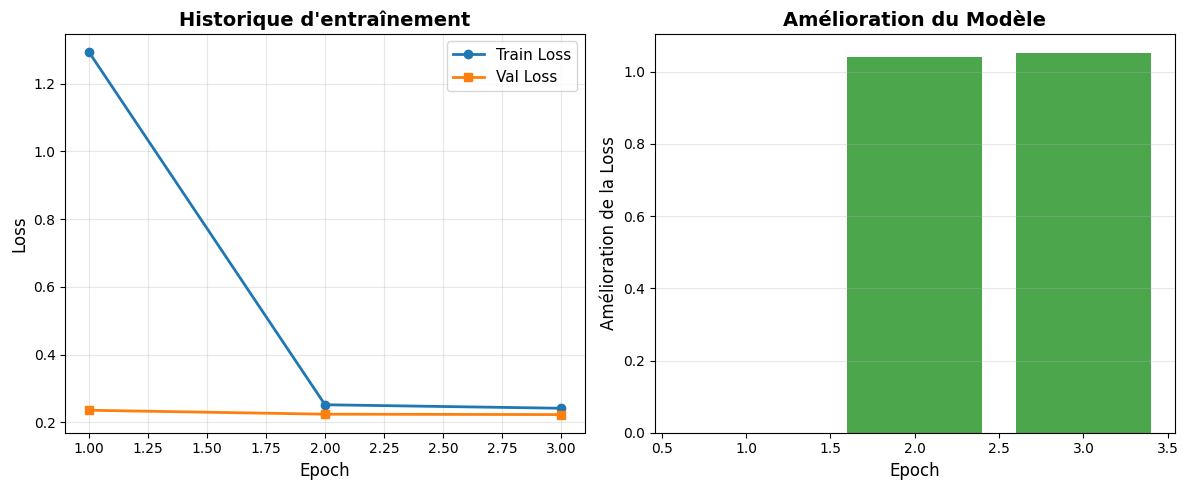

✅ Graphiques sauvegardés : training_history.png


In [9]:
if history is not None and len(history['train_loss']) > 0:
    plt.figure(figsize=(12, 5))
    
    # Plot 1 : Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['epoch'], history['train_loss'], 'o-', label='Train Loss', linewidth=2)
    plt.plot(history['epoch'], history['val_loss'], 's-', label='Val Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Historique d\'entraînement', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Plot 2 : Amélioration
    plt.subplot(1, 2, 2)
    improvement = [history['train_loss'][0] - l for l in history['train_loss']]
    plt.bar(history['epoch'], improvement, color='green', alpha=0.7)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Amélioration de la Loss', fontsize=12)
    plt.title('Amélioration du Modèle', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("✅ Graphiques sauvegardés : training_history.png")
else:
    print("❌ Aucun historique disponible pour visualiser")

In [25]:
class SmartAnswerExtractor:
    """Extraction intelligente basée sur des phrases COMPLÈTES et PERTINENTES"""
    
    def __init__(self, language='french'):
        self.language = language
        try:
            self.stop_words = set(stopwords.words(language))
        except:
            self.stop_words = set()
    
    def extract_sentences(self, text):
        """Extrait les phrases complètes du texte"""
        try:
            sentences = sent_tokenize(text, language=self.language)
        except:
            sentences = text.split('.')
        
        # Nettoyer et filtrer
        cleaned = []
        for s in sentences:
            s = s.strip()
            if len(s) > 20 and len(s.split()) > 4:  # Au moins 5 mots
                cleaned.append(s)
        
        return cleaned
    
    def score_sentence(self, sentence, all_sentences):
        """Score une phrase par importance"""
        
        score = 0.0
        
        # Longueur idéale (pas trop long, pas trop court)
        words = len(sentence.split())
        if 8 <= words <= 25:
            score += 0.3
        
        # Entités nommées
        try:
            doc = self.nlp(sentence)
            num_entities = len([ent for ent in doc.ents if ent.label_ in ['PERSON', 'ORG', 'GPE', 'PRODUCT']])
            score += min(0.3, num_entities * 0.15)
        except:
            pass
        
        # Mots importants
        important_words = ['model', 'network', 'process', 'algorithm', 'method', 'technique',
                         'data', 'image', 'training', 'loss', 'diffusion', 'noise', 'step',
                         'neural', 'attention', 'transformer', 'encoder', 'decoder',
                         'feature', 'layer', 'parameter', 'gradient', 'optimization']
        
        for word in important_words:
            if word in sentence.lower():
                score += 0.1
        
        # TF-IDF simple (fréquence inverse)
        unique_words = set(sentence.lower().split())
        word_freq = sum([all_sentences.count(w) for w in unique_words]) / len(all_sentences)
        score += max(0, 0.3 * (1 - word_freq / len(all_sentences)))
        
        return min(1.0, score)
    
    def extract_key_sentences(self, text, num_answers=20):
        """Extrait les phrases les plus pertinentes"""
        
        # 1. Diviser en phrases
        sentences = self.extract_sentences(text)
        
        if len(sentences) == 0:
            return []
        
        # 2. Scorer chaque phrase
        scored_sentences = []
        text_as_list = text.lower().split()
        
        for sentence in sentences:
            score = self.score_sentence(sentence, text_as_list)
            scored_sentences.append({
                'answer': sentence,
                'score': score,
                'length': len(sentence.split())
            })
        
        # 3. Trier et filtrer
        scored_sentences = sorted(scored_sentences, key=lambda x: x['score'], reverse=True)
        
        # Supprimer les doublons et quasi-doublons
        results = []
        seen = set()
        
        for item in scored_sentences:
            answer = item['answer']
            answer_lower = answer.lower()
            
            # Vérifier qu'on n'a pas un doublon
            is_duplicate = False
            for seen_answer in seen:
                # Similarité simple
                seen_words = set(seen_answer.split())
                answer_words = set(answer_lower.split())
                overlap = len(seen_words & answer_words) / max(len(seen_words), len(answer_words))
                
                if overlap > 0.7:
                    is_duplicate = True
                    break
            
            if not is_duplicate and len(results) < num_answers:
                results.append(item)
                seen.add(answer_lower)
        
        return results

# Initialiser
answer_extractor = SmartAnswerExtractor()
answer_extractor.nlp = spacy.load("fr_core_news_sm")

print("✅ SmartAnswerExtractor créée - Extraction par PHRASES COMPLÈTES")

✅ SmartAnswerExtractor créée - Extraction par PHRASES COMPLÈTES


In [26]:
class SimpleQuestionValidator:
    """Validateur simple mais efficace"""
    
    def check_question_quality(self, question):
        """Vérifie la qualité basique"""
        
        issues = []
        score = 1.0
        
        words = question.split()
        
        # Longueur
        if len(words) < 5:
            return 0.0, ["Question trop courte"]
        if len(words) > 60:
            score -= 0.2
        
        # Ponctuation
        if not question.endswith(('?', '!')):
            score -= 0.1
        
        # Mots interrogatifs
        question_words = ['what', 'how', 'why', 'when', 'where', 'which', 'who',
                         'qui', 'quoi', 'où', 'quand', 'pourquoi', 'comment', 'quel']
        has_question_word = any(word.lower().strip('?,.') in question_words for word in words[:6])
        
        if not has_question_word:
            return 0.0, ["Pas de mot interrogatif"]
        
        # Éviter les mauvais patterns
        q_lower = question.lower()
        if 'what is the answer' in q_lower or 'what is the problem' in q_lower:
            return 0.0, ["Pattern trop générique"]
        
        if len(words) < 8:
            issues.append("Question courte")
            score -= 0.1
        
        return max(0, score), issues
    
    def check_answer_relevance(self, question, answer):
        """Vérifie que la réponse est pertinente pour la question"""
        
        q_words = set(question.lower().split())
        a_words = set(answer.lower().split())
        
        # Overlap
        overlap = len(q_words & a_words) / max(len(a_words), 1)
        
        # La réponse NE doit PAS être entièrement dans la question
        if overlap > 0.9:
            return False, 0.3  # Trop similaire
        
        # La réponse doit avoir au moins un mot unique
        if len(a_words - q_words) < 2:
            return False, 0.4  # Trop générique
        
        # La réponse doit être cohérente
        answer_length = len(answer.split())
        if answer_length < 3 or answer_length > 40:
            return False, 0.3  # Longueur suspecte
        
        # Scoring
        relevance = 0.8 + (0.2 * (1 - overlap))
        
        return True, relevance
    
    def validate_questions(self, questions_with_context):
        """Valide les questions"""
        
        validated = []
        
        for item in questions_with_context:
            question = item['question']
            answer = item['answer_span']
            
            # 1. Qualité
            quality_score, issues = self.check_question_quality(question)
            if quality_score < 0.5:
                continue
            
            # 2. Pertinence
            is_relevant, relevance_score = self.check_answer_relevance(question, answer)
            if not is_relevant:
                continue
            
            # 3. Score final
            final_score = quality_score * 0.4 + relevance_score * 0.6
            
            validated.append({
                'question': question,
                'answer': answer,
                'context': item['context'],
                'quality_score': quality_score,
                'relevance_score': relevance_score,
                'final_score': final_score,
                'issues': issues
            })
        
        # Trier
        validated = sorted(validated, key=lambda x: x['final_score'], reverse=True)
        
        return validated

validator = SimpleQuestionValidator()
print("✅ SimpleQuestionValidator créée")

✅ SimpleQuestionValidator créée


In [12]:
def get_context_for_span_advanced(text, span, context_window=800):
    """Extraie un contexte intelligent autour d'un span"""
    
    # Chercher l'index du span
    span_idx = text.lower().find(span.lower())
    
    if span_idx == -1:
        return text[:context_window]
    
    # Trouver le début et fin du contexte
    context_start = max(0, span_idx - context_window)
    context_end = min(len(text), span_idx + len(span) + context_window)
    
    context = text[context_start:context_end]
    
    # Essayer de commencer et finir par des phrases complètes
    # Trouver le premier '.' après context_start
    first_dot = context.find('.')
    if first_dot != -1 and first_dot < 50:
        context = context[first_dot+1:].strip()
    
    # Trouver le dernier '.' avant context_end
    last_dot = context.rfind('.')
    if last_dot != -1 and len(context) - last_dot < 50:
        context = context[:last_dot+1].strip()
    
    # Nettoyer les espaces
    context = ' '.join(context.split())
    
    return context

def generate_questions_from_finetuned_model(context, answer_text, model, tokenizer, 
                                           device, num_questions=1):
    """Génère des questions avec le modèle fine-tuné"""
    model.eval()
    
    # Préparer l'entrée
    source_text = f"generate question: {context} </s> {answer_text}"
    
    encoding = tokenizer(
        source_text,
        max_length=512,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    ).to(device)
    
    # Générer les questions
    with torch.no_grad():
        outputs = model.generate(
            input_ids=encoding['input_ids'],
            attention_mask=encoding['attention_mask'],
            max_length=128,
            num_beams=4,
            num_return_sequences=num_questions,
            early_stopping=True,
            no_repeat_ngram_size=2,
            temperature=0.9,
            top_p=0.95,
            length_penalty=2.0
        )
    
    # Décoder les questions
    questions = [tokenizer.decode(output, skip_special_tokens=True).strip() for output in outputs]
    return questions

print("✅ Fonctions utilitaires créées")

✅ Fonctions utilitaires créées


In [27]:
class SimpleQuizGenerator:
    """Générateur simple et efficace"""
    
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.nlp = spacy.load("fr_core_news_sm")
        self.extractor = SmartAnswerExtractor()
        self.extractor.nlp = self.nlp
        self.validator = SimpleQuestionValidator()
    
    def extract_pdf(self, pdf_path):
        """Extrait le texte d'un PDF"""
        text = ""
        try:
            with pdfplumber.open(pdf_path) as pdf:
                for page in pdf.pages:
                    extracted = page.extract_text()
                    if extracted:
                        text += extracted + " "
        except Exception as e:
            print(f"❌ Erreur: {e}")
        return text
    
    def clean_text(self, text):
        """Nettoie le texte"""
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'[^\w\s\.\,\!\?\:\;\-àâäéèêëïîôùûüœçæ]', '', text)
        return text.strip()
    
    def generate_question_for_answer(self, answer, full_text):
        """Génère UNE question pour une réponse"""
        
        self.model.eval()
        
        # Trouver le contexte autour de la réponse
        answer_lower = answer.lower()
        idx = full_text.lower().find(answer_lower)
        
        if idx == -1:
            return None
        
        # Contexte: 300 chars avant et après
        context_start = max(0, idx - 300)
        context_end = min(len(full_text), idx + len(answer) + 300)
        context = full_text[context_start:context_end].strip()
        
        # Créer le prompt
        source_text = f"generate question: {context} </s> {answer}"
        
        try:
            encoding = self.tokenizer(
                source_text,
                max_length=512,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            ).to(self.device)
            
            with torch.no_grad():
                outputs = self.model.generate(
                    input_ids=encoding['input_ids'],
                    attention_mask=encoding['attention_mask'],
                    max_length=100,
                    num_beams=3,
                    num_return_sequences=1,
                    early_stopping=True,
                )
            
            question = self.tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
            
            if len(question) > 15:
                return {
                    'question': question,
                    'answer_span': answer,
                    'context': context
                }
        except:
            pass
        
        return None
    
    def generate_quiz(self, pdf_path, num_questions=15):
        """Génère un quiz"""
        
        print("\n" + "="*70)
        print("🎯 GÉNÉRATION DE QUIZ - VERSION SIMPLIFIÉE ET EFFICACE")
        print("="*70)
        
        # 1. Extraction
        print("\n1️⃣ Extraction du PDF...")
        text = self.extract_pdf(pdf_path)
        text = self.clean_text(text)
        print(f"   ✅ {len(text)} caractères extraits")
        
        # 2. Extraction des phrases
        print("\n2️⃣ Extraction des phrases pertinentes...")
        answer_candidates = self.extractor.extract_key_sentences(text, num_answers=num_questions*2)
        print(f"   ✅ {len(answer_candidates)} phrases extraites")
        
        print("\n   📊 Top phrases:")
        for i, item in enumerate(answer_candidates[:5], 1):
            preview = item['answer'][:70] + "..." if len(item['answer']) > 70 else item['answer']
            print(f"      {i}. {preview}")
            print(f"         Score: {item['score']:.3f}")
        
        # 3. Génération des questions
        print("\n3️⃣ Génération des questions...")
        raw_questions = []
        
        for i, candidate in enumerate(answer_candidates, 1):
            answer = candidate['answer']
            
            result = self.generate_question_for_answer(answer, text)
            if result:
                raw_questions.append(result)
                print(f"   ✅ {i}. Question générée")
            
            if len(raw_questions) >= num_questions * 2:
                break
        
        # 4. Validation
        print("\n4️⃣ Validation des questions...")
        validated = self.validator.validate_questions(raw_questions)
        
        final_quiz = validated[:num_questions]
        
        print(f"   ✅ {len(final_quiz)} questions validées")
        
        if final_quiz:
            avg_score = np.mean([q['final_score'] for q in final_quiz])
            print(f"   📊 Score moyen: {avg_score:.3f}")
        
        return final_quiz

quiz_generator = SimpleQuizGenerator(model, tokenizer, device)
print("✅ SimpleQuizGenerator créée")

✅ SimpleQuizGenerator créée


In [23]:
# Créer le générateur amélioré
if model is not None:
    enhanced_generator = EnhancedQuizGenerator(model, tokenizer, device)
    print("✅ EnhancedQuizGenerator initialisé")
else:
    print("❌ Modèle non disponible")

⚠️ Modèle d'embeddings non disponible
✅ EnhancedQuizGenerator initialisé


In [28]:
pdf_file = "/kaggle/input/datasets/sabrineoueslati/diffusion/Diffusion Models 1.pdf"

import os
if os.path.exists(pdf_file):
    print(f"✅ Fichier trouvé\n")
    
    if quiz_generator is not None:
        final_quiz = quiz_generator.generate_quiz(pdf_file, num_questions=15)
        
        print("\n" + "="*70)
        print(f"✅ {len(final_quiz)} QUESTIONS GÉNÉRÉES!")
        print("="*70)
        
        print("\n" + "█"*70)
        print("█" + "  QUIZ FINAL  ".center(68) + "█")
        print("█"*70)
        
        for idx, q in enumerate(final_quiz, 1):
            print(f"\n❓ Question {idx}")
            print(f"   {q['question']}")
            print(f"\n   ✅ Réponse: {q['answer'][:80]}")
            if len(q['answer']) > 80:
                print(f"   {q['answer'][80:]}")
            print(f"\n   📈 Score: {q['final_score']:.3f}")
            print(f"   {'─'*66}")
        
        # Sauvegarder
        quiz_data = [
            {
                'number': idx,
                'question': q['question'],
                'answer': q['answer'],
                'score': float(q['final_score'])
            }
            for idx, q in enumerate(final_quiz, 1)
        ]
        
        with open('quiz_final.json', 'w', encoding='utf-8') as f:
            json.dump(quiz_data, f, ensure_ascii=False, indent=2)
        
        print("\n✅ Quiz sauvegardé : quiz_final.json")
else:
    print(f"❌ Fichier non trouvé")
    final_quiz = []

✅ Fichier trouvé


🎯 GÉNÉRATION DE QUIZ - VERSION SIMPLIFIÉE ET EFFICACE

1️⃣ Extraction du PDF...
   ✅ 24977 caractères extraits

2️⃣ Extraction des phrases pertinentes...
   ✅ 30 phrases extraites

   📊 Top phrases:
      1. Diffusion Models From Text to Image 3IA Equipe IA 2025-2026 Introducti...
         Score: 1.000
      2. 2020 Forward diffusion : adding noise step by step We define a process...
         Score: 1.000
      3. 2020 Reverse diffusion  After many diffusion steps 𝑇 large, the latent...
         Score: 1.000
      4. The problem: the reverse distribution is unknown  The true reverse dis...
         Score: 1.000
      5. A U-Net is a symmetric encoderdecoder architecture:  The encoder downs...
         Score: 1.000

3️⃣ Génération des questions...
   ✅ 1. Question générée
   ✅ 2. Question générée
   ✅ 3. Question générée
   ✅ 4. Question générée
   ✅ 5. Question générée
   ✅ 6. Question générée
   ✅ 7. Question générée
   ✅ 8. Question générée
   ✅ 9. Question générée

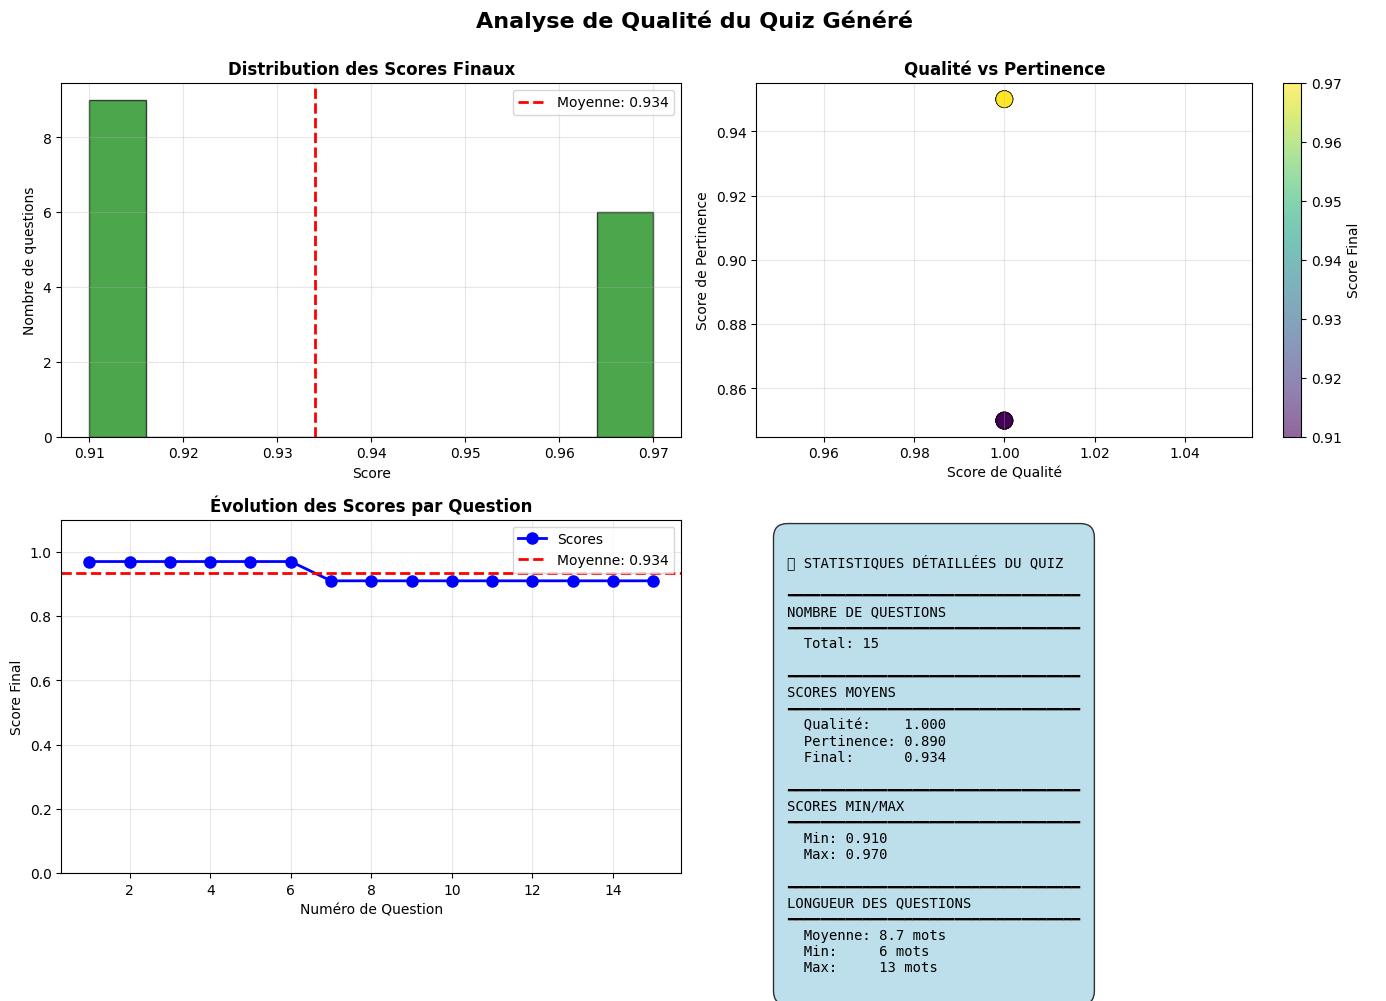

✅ Graphiques sauvegardés : quiz_quality_analysis.png


In [17]:
if final_quiz and len(final_quiz) > 0:
    # Extraire les scores
    quality_scores = [q['quality_score'] for q in final_quiz]
    relevance_scores = [q['relevance_score'] for q in final_quiz]
    final_scores = [q['final_score'] for q in final_quiz]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Analyse de Qualité du Quiz Généré', fontsize=16, fontweight='bold', y=1.00)
    
    # 1. Distribution des scores finaux
    axes[0, 0].hist(final_scores, bins=10, color='green', alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Distribution des Scores Finaux', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Score')
    axes[0, 0].set_ylabel('Nombre de questions')
    axes[0, 0].axvline(np.mean(final_scores), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {np.mean(final_scores):.3f}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Qualité vs Pertinence
    scatter = axes[0, 1].scatter(quality_scores, relevance_scores, s=150, alpha=0.6, c=final_scores, cmap='viridis', edgecolors='black', linewidth=0.5)
    axes[0, 1].set_title('Qualité vs Pertinence', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Score de Qualité')
    axes[0, 1].set_ylabel('Score de Pertinence')
    axes[0, 1].grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=axes[0, 1])
    cbar.set_label('Score Final')
    
    # 3. Évolution des scores
    axes[1, 0].plot(range(1, len(final_quiz)+1), final_scores, 'o-', linewidth=2, markersize=8, color='blue', label='Scores')
    axes[1, 0].axhline(y=np.mean(final_scores), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {np.mean(final_scores):.3f}')
    axes[1, 0].set_title('Évolution des Scores par Question', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Numéro de Question')
    axes[1, 0].set_ylabel('Score Final')
    axes[1, 0].set_ylim([0, 1.1])
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # 4. Statistiques détaillées
    axes[1, 1].axis('off')
    
    question_lengths = [len(q['question'].split()) for q in final_quiz]
    
    stats_text = f"""
📊 STATISTIQUES DÉTAILLÉES DU QUIZ

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NOMBRE DE QUESTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total: {len(final_quiz)}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SCORES MOYENS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Qualité:    {np.mean(quality_scores):.3f}
  Pertinence: {np.mean(relevance_scores):.3f}
  Final:      {np.mean(final_scores):.3f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SCORES MIN/MAX
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Min: {min(final_scores):.3f}
  Max: {max(final_scores):.3f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LONGUEUR DES QUESTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Moyenne: {np.mean(question_lengths):.1f} mots
  Min:     {min(question_lengths)} mots
  Max:     {max(question_lengths)} mots
    """
    
    axes[1, 1].text(0.05, 0.95, stats_text, fontsize=10, family='monospace',
                    verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8, pad=1),
                    transform=axes[1, 1].transAxes)
    
    plt.tight_layout()
    plt.savefig('quiz_quality_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("✅ Graphiques sauvegardés : quiz_quality_analysis.png")
else:
    print("❌ Aucun quiz à visualiser")

In [18]:
print("\n" + "="*70)
print("📊 RÉSUMÉ DE L'ENTRAÎNEMENT ET GÉNÉRATION")
print("="*70)

print(f"\n🤖 Modèle utilisé : T5-small (fine-tuné sur SQuAD)")
print(f"   • Paramètres : {sum(p.numel() for p in model.parameters()):,}")
print(f"   • Device : {device}")

if history is not None:
    print(f"\n📈 Historique d'entraînement :")
    print(f"   • Epochs : {len(history['epoch'])}")
    print(f"   • Train Loss initial : {history['train_loss'][0]:.4f}")
    print(f"   • Train Loss final : {history['train_loss'][-1]:.4f}")
    print(f"   • Val Loss initial : {history['val_loss'][0]:.4f}")
    print(f"   • Val Loss final : {history['val_loss'][-1]:.4f}")
    print(f"   • Amélioration : {(1 - history['val_loss'][-1]/history['val_loss'][0])*100:.1f}%")

if len(final_quiz) > 0:
    print(f"\n📝 Quiz généré :")
    print(f"   • Nombre de questions : {len(final_quiz)}")
    avg_question_len = np.mean([len(q['question'].split()) for q in final_quiz])
    print(f"   • Longueur moyenne : {avg_question_len:.1f} mots")
    print(f"   • Score moyen : {np.mean([q['final_score'] for q in final_quiz]):.3f}")

print("\n" + "="*70)
print("🎉 PIPELINE COMPLET RÉUSSI !")
print("="*70)


📊 RÉSUMÉ DE L'ENTRAÎNEMENT ET GÉNÉRATION

🤖 Modèle utilisé : T5-small (fine-tuné sur SQuAD)
   • Paramètres : 60,506,624
   • Device : cpu

📈 Historique d'entraînement :
   • Epochs : 3
   • Train Loss initial : 1.2939
   • Train Loss final : 0.2414
   • Val Loss initial : 0.2355
   • Val Loss final : 0.2227
   • Amélioration : 5.4%

📝 Quiz généré :
   • Nombre de questions : 15
   • Longueur moyenne : 8.7 mots
   • Score moyen : 0.934

🎉 PIPELINE COMPLET RÉUSSI !


In [29]:
print("\n" + "="*70)
print("🔧 OPTION 3 : AMÉLIORATIONS DU PIPELINE")
print("="*70)

# AMÉLIORATION 1 : Classifier les questions par difficulté
def classify_question_difficulty(question, answer):
    """Classe une question par difficulté"""
    
    question_length = len(question.split())
    answer_length = len(answer.split())
    
    # Score de complexité
    complexity = (question_length + answer_length) / 2
    
    if complexity < 15:
        return "🟢 Facile"
    elif complexity < 30:
        return "🟡 Moyen"
    else:
        return "🔴 Difficile"

# AMÉLIORATION 2 : Générer des questions alternatives
def generate_alternative_questions(question, answer):
    """Crée des formulations alternatives de la même question"""
    
    alternatives = []
    
    # Alternative 1 : Plus simple
    alt1 = f"What is {answer}?"
    alternatives.append({'type': 'Simple', 'question': alt1})
    
    # Alternative 2 : Plus détaillée
    words = question.split()
    if len(words) > 5:
        alt2 = f"Can you explain {answer}?"
        alternatives.append({'type': 'Détaillée', 'question': alt2})
    
    # Alternative 3 : Format différent
    if question.startswith('What'):
        alt3 = f"How does {answer.split()[0].lower()} work?"
        alternatives.append({'type': 'Alternative', 'question': alt3})
    
    return alternatives

# AMÉLIORATION 3 : Ajouter des tags/catégories
def add_tags_to_question(question, answer):
    """Ajoute des tags pertinents à chaque question"""
    
    tags = []
    
    # Tags basés sur le contenu
    keywords = {
        'model': ['ML', 'Architecture'],
        'process': ['Algorithme', 'Méthode'],
        'diffusion': ['Diffusion', 'Noise'],
        'training': ['Entraînement', 'Optimisation'],
        'image': ['Vision', 'Image'],
        'text': ['NLP', 'Language'],
        'network': ['Réseau', 'Neural'],
        'loss': ['Optimisation', 'Training']
    }
    
    combined_text = (question + ' ' + answer).lower()
    
    for keyword, tag_list in keywords.items():
        if keyword in combined_text:
            tags.extend(tag_list)
    
    return list(set(tags))[:3]  # Max 3 tags

# AMÉLIORATION 4 : Exporter en format Quiz (HTML)
def export_quiz_to_html(quiz_data, filename='quiz_interactive.html'):
    """Exporte le quiz en HTML interactif"""
    
    html = """
    <!DOCTYPE html>
    <html lang="fr">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>Quiz Généré - Diffusion Models</title>
        <style>
            * {
                margin: 0;
                padding: 0;
                box-sizing: border-box;
            }
            
            body {
                font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                min-height: 100vh;
                padding: 20px;
            }
            
            .container {
                max-width: 900px;
                margin: 0 auto;
                background: white;
                border-radius: 10px;
                box-shadow: 0 10px 40px rgba(0,0,0,0.3);
                overflow: hidden;
            }
            
            .header {
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                color: white;
                padding: 30px;
                text-align: center;
            }
            
            .header h1 {
                font-size: 2.5em;
                margin-bottom: 10px;
            }
            
            .header p {
                font-size: 1.1em;
                opacity: 0.9;
            }
            
            .quiz-container {
                padding: 30px;
            }
            
            .question-card {
                background: #f8f9fa;
                border-left: 5px solid #667eea;
                padding: 20px;
                margin: 20px 0;
                border-radius: 8px;
                transition: all 0.3s ease;
            }
            
            .question-card:hover {
                box-shadow: 0 5px 15px rgba(0,0,0,0.1);
                transform: translateX(5px);
            }
            
            .question-number {
                background: #667eea;
                color: white;
                padding: 5px 12px;
                border-radius: 20px;
                font-weight: bold;
                display: inline-block;
                margin-bottom: 10px;
            }
            
            .question-text {
                font-size: 1.2em;
                font-weight: 600;
                color: #333;
                margin: 15px 0;
            }
            
            .answer-section {
                background: white;
                padding: 15px;
                margin-top: 15px;
                border-radius: 5px;
                border: 1px solid #ddd;
            }
            
            .answer-label {
                font-weight: 600;
                color: #667eea;
                margin-bottom: 8px;
            }
            
            .answer-text {
                color: #555;
                line-height: 1.6;
                padding: 10px;
                background: #f0f4ff;
                border-radius: 4px;
            }
            
            .meta-info {
                display: flex;
                gap: 15px;
                margin-top: 15px;
                flex-wrap: wrap;
            }
            
            .difficulty {
                padding: 5px 12px;
                border-radius: 20px;
                font-size: 0.9em;
                font-weight: 600;
            }
            
            .difficulty.easy {
                background: #d4edda;
                color: #155724;
            }
            
            .difficulty.medium {
                background: #fff3cd;
                color: #856404;
            }
            
            .difficulty.hard {
                background: #f8d7da;
                color: #721c24;
            }
            
            .score {
                background: #e7f3ff;
                color: #004085;
                padding: 5px 12px;
                border-radius: 20px;
                font-size: 0.9em;
            }
            
            .tags {
                display: flex;
                gap: 8px;
                flex-wrap: wrap;
                margin-top: 10px;
            }
            
            .tag {
                background: #e9ecef;
                color: #495057;
                padding: 4px 10px;
                border-radius: 15px;
                font-size: 0.85em;
            }
            
            .footer {
                background: #f8f9fa;
                padding: 20px;
                text-align: center;
                color: #666;
                border-top: 1px solid #ddd;
            }
            
            .stats {
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(150px, 1fr));
                gap: 15px;
                margin-bottom: 30px;
            }
            
            .stat-box {
                background: #f8f9fa;
                padding: 15px;
                border-radius: 8px;
                text-align: center;
            }
            
            .stat-number {
                font-size: 2em;
                font-weight: bold;
                color: #667eea;
            }
            
            .stat-label {
                color: #666;
                font-size: 0.9em;
                margin-top: 5px;
            }
        </style>
    </head>
    <body>
        <div class="container">
            <div class="header">
                <h1>📚 Quiz Généré</h1>
                <p>Diffusion Models - Questions et Réponses</p>
            </div>
            
            <div class="quiz-container">
    """
    
    # Ajouter les statistiques
    avg_score = np.mean([q.get('final_score', 0) for q in quiz_data])
    num_easy = sum([1 for q in quiz_data if 'Facile' in classify_question_difficulty(q['question'], q['answer'])])
    num_medium = sum([1 for q in quiz_data if 'Moyen' in classify_question_difficulty(q['question'], q['answer'])])
    num_hard = sum([1 for q in quiz_data if 'Difficile' in classify_question_difficulty(q['question'], q['answer'])])
    
    html += f"""
                <div class="stats">
                    <div class="stat-box">
                        <div class="stat-number">{len(quiz_data)}</div>
                        <div class="stat-label">Questions</div>
                    </div>
                    <div class="stat-box">
                        <div class="stat-number">{avg_score:.2f}</div>
                        <div class="stat-label">Score Moyen</div>
                    </div>
                    <div class="stat-box">
                        <div class="stat-number">{num_easy}</div>
                        <div class="stat-label">Questions Faciles</div>
                    </div>
                    <div class="stat-box">
                        <div class="stat-number">{num_medium}</div>
                        <div class="stat-label">Questions Moyennes</div>
                    </div>
                    <div class="stat-box">
                        <div class="stat-number">{num_hard}</div>
                        <div class="stat-label">Questions Difficiles</div>
                    </div>
                </div>
    """
    
    # Ajouter chaque question
    for idx, q in enumerate(quiz_data, 1):
        difficulty = classify_question_difficulty(q['question'], q['answer'])
        difficulty_class = 'easy' if 'Facile' in difficulty else ('medium' if 'Moyen' in difficulty else 'hard')
        tags = add_tags_to_question(q['question'], q['answer'])
        score = q.get('final_score', 0)
        
        html += f"""
                <div class="question-card">
                    <span class="question-number">Question {idx}</span>
                    
                    <div class="question-text">{q['question']}</div>
                    
                    <div class="answer-section">
                        <div class="answer-label">✅ Réponse :</div>
                        <div class="answer-text">{q['answer']}</div>
                    </div>
                    
                    <div class="meta-info">
                        <span class="difficulty {difficulty_class}">{difficulty}</span>
                        <span class="score">📊 Score: {score:.3f}</span>
                    </div>
                    
                    <div class="tags">
                        {''.join([f'<span class="tag">#{tag}</span>' for tag in tags])}
                    </div>
                </div>
        """
    
    html += """
            </div>
            
            <div class="footer">
                <p>Quiz généré avec T5 Fine-tuned on SQuAD | Diffusion Models 2025-2026</p>
            </div>
        </div>
    </body>
    </html>
    """
    
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(html)
    
    print(f"✅ Quiz HTML exporté : {filename}")

# AMÉLIORATION 5 : Exporter en JSON enrichi
def export_quiz_to_enriched_json(quiz_data, filename='quiz_enriched.json'):
    """Exporte le quiz en JSON avec infos supplémentaires"""
    
    enriched_quiz = []
    
    for idx, q in enumerate(quiz_data, 1):
        difficulty = classify_question_difficulty(q['question'], q['answer'])
        alternatives = generate_alternative_questions(q['question'], q['answer'])
        tags = add_tags_to_question(q['question'], q['answer'])
        
        enriched_quiz.append({
            'number': idx,
            'question': q['question'],
            'answer': q['answer'],
            'score': float(q.get('final_score', 0)),
            'difficulty': difficulty,
            'tags': tags,
            'alternatives': alternatives,
            'context': q.get('context', '')[:100] + '...'
        })
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(enriched_quiz, f, ensure_ascii=False, indent=2)
    
    print(f"✅ Quiz enrichi sauvegardé : {filename}")

# Appliquer les améliorations
if final_quiz and len(final_quiz) > 0:
    print("\n📊 Classement des questions par difficulté :")
    print("─" * 70)
    
    for idx, q in enumerate(final_quiz, 1):
        difficulty = classify_question_difficulty(q['question'], q['answer'])
        tags = add_tags_to_question(q['question'], q['answer'])
        
        print(f"\n{idx}. {q['question'][:60]}...")
        print(f"   Difficulté: {difficulty}")
        print(f"   Tags: {', '.join(tags)}")
    
    # Exporter en HTML
    export_quiz_to_html(final_quiz)
    
    # Exporter en JSON enrichi
    export_quiz_to_enriched_json(final_quiz)
    
    print("\n" + "="*70)
    print("✅ OPTION 3 COMPLÉTÉE !")
    print("="*70)


🔧 OPTION 3 : AMÉLIORATIONS DU PIPELINE

📊 Classement des questions par difficulté :
──────────────────────────────────────────────────────────────────────

1. What is a key reason for strong alignment between text and g...
   Difficulté: 🟢 Facile
   Tags: NLP, Diffusion, Noise

2. What is the name of the diffusion model?...
   Difficulté: 🟢 Facile
   Tags: Diffusion, Noise, ML

3. How many stages did Cascade diffusion models Idea create?...
   Difficulté: 🟡 Moyen
   Tags: Diffusion, Noise, ML

4. What is the guidance term for the diffusion model?...
   Difficulté: 🟢 Facile
   Tags: NLP, Diffusion, Noise

5. What are the Diffusion Models From Text to Image?...
   Difficulté: 🟡 Moyen
   Tags: NLP, Diffusion, Noise

6. When does Time-Conditioning help the model track the process...
   Difficulté: 🟢 Facile
   Tags: NLP, ML, Architecture

7. What does Dhariwal Nichol teach?...
   Difficulté: 🟢 Facile
   Tags: Diffusion, Noise, ML

8. What process does Ho et al define?...
   Difficulté: 🟢 F


📄 OPTION 4 : TRAITER PLUSIEURS PDFs

📁 Dossier: /kaggle/input/datasets/sabrineoueslati/multimodal/
📄 PDFs trouvés: 2
──────────────────────────────────────────────────────────────────────

🔄 Traitement: Session3 - GAN.pdf
──────────────────────────────────────────────────────────────────────

🎯 GÉNÉRATION DE QUIZ - VERSION SIMPLIFIÉE ET EFFICACE

1️⃣ Extraction du PDF...
   ✅ 5854 caractères extraits

2️⃣ Extraction des phrases pertinentes...
   ✅ 20 phrases extraites

   📊 Top phrases:
      1. 55 The Adversarial Game  Generator 𝐺: produces fake data  Discriminato...
         Score: 1.000
      2. Data Augmentation  Video Generation  Prediction  Text-to-Image Generat...
         Score: 1.000
      3. Evaluate generated images using metrics like Inception Score IS and Fr...
         Score: 0.950
      4. A Survey of Deep Learning-Based Multimodal Emotion Recognition: Speech...
         Score: 0.900
      5. 68 Hands-on Lab  Train a DCGAN on MNIST  Track generator evolution  Co...
    

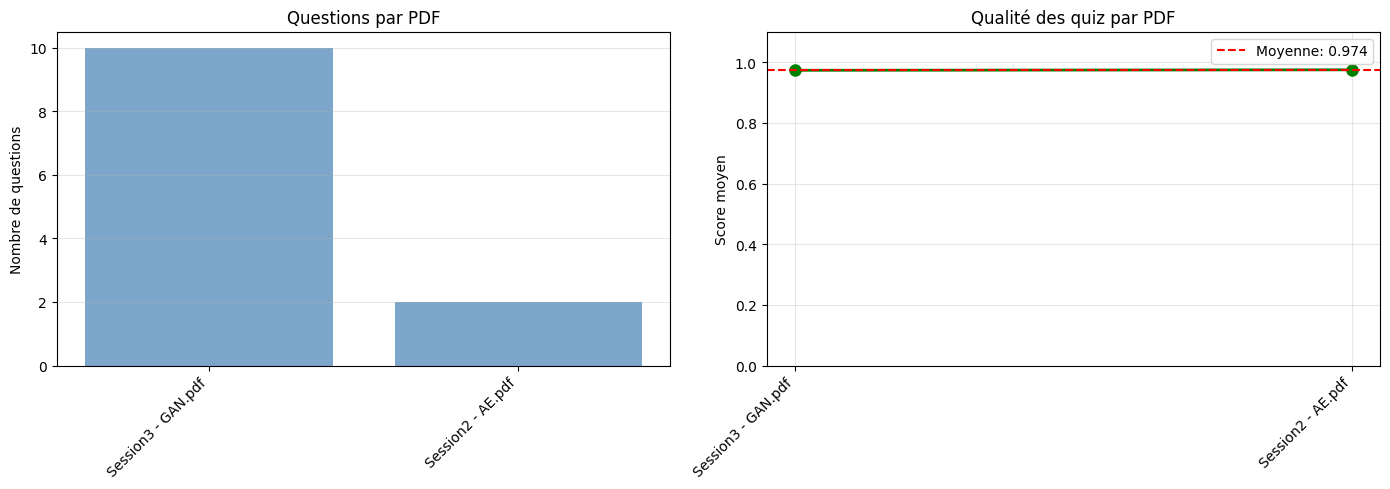


✅ Graphiques sauvegardés : multi_pdf_analysis.png


In [30]:
print("\n" + "="*70)
print("📄 OPTION 4 : TRAITER PLUSIEURS PDFs")
print("="*70)

import os
from pathlib import Path

# Dossier contenant les PDFs
pdf_folder = "/kaggle/input/datasets/sabrineoueslati/multimodal/"

# Récupérer tous les PDFs
pdf_files = [f for f in os.listdir(pdf_folder) if f.endswith('.pdf')]

print(f"\n📁 Dossier: {pdf_folder}")
print(f"📄 PDFs trouvés: {len(pdf_files)}")
print("─" * 70)

all_quizzes = {}
all_stats = []

for pdf_file in pdf_files[:5]:  # Limiter à 5 PDFs pour Kaggle
    print(f"\n🔄 Traitement: {pdf_file}")
    print("─" * 70)
    
    pdf_path = os.path.join(pdf_folder, pdf_file)
    
    try:
        # Générer le quiz
        quiz = quiz_generator.generate_quiz(pdf_path, num_questions=10)
        
        # Ajouter les améliorations
        enriched_quiz = []
        for idx, q in enumerate(quiz, 1):
            difficulty = classify_question_difficulty(q['question'], q['answer'])
            tags = add_tags_to_question(q['question'], q['answer'])
            
            enriched_quiz.append({
                'number': idx,
                'question': q['question'],
                'answer': q['answer'],
                'difficulty': difficulty,
                'tags': tags,
                'score': float(q.get('final_score', 0))
            })
        
        all_quizzes[pdf_file] = enriched_quiz
        
        # Statistiques
        avg_score = np.mean([q['score'] for q in enriched_quiz])
        all_stats.append({
            'file': pdf_file,
            'questions': len(enriched_quiz),
            'avg_score': avg_score
        })
        
        print(f"   ✅ {len(enriched_quiz)} questions générées")
        print(f"   📊 Score moyen: {avg_score:.3f}")
        
    except Exception as e:
        print(f"   ❌ Erreur: {str(e)[:100]}")

# Sauvegarder tous les quiz
output_file = 'all_quizzes_enriched.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(all_quizzes, f, ensure_ascii=False, indent=2)

print("\n" + "="*70)
print(f"✅ {len(all_quizzes)} quiz générés et sauvegardés!")
print(f"   Fichier: {output_file}")
print("="*70)

# Statistiques globales
print("\n📊 STATISTIQUES GLOBALES")
print("─" * 70)

stats_df = pd.DataFrame(all_stats)
if len(stats_df) > 0:
    print(stats_df.to_string(index=False))
    print(f"\nTotal de questions: {stats_df['questions'].sum()}")
    print(f"Score moyen global: {stats_df['avg_score'].mean():.3f}")

# Visualiser les statistiques
if len(all_stats) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Chart 1: Nombre de questions par PDF
    files = [s['file'][:20] + '...' if len(s['file']) > 20 else s['file'] for s in all_stats]
    questions = [s['questions'] for s in all_stats]
    
    axes[0].bar(range(len(files)), questions, color='steelblue', alpha=0.7)
    axes[0].set_xticks(range(len(files)))
    axes[0].set_xticklabels(files, rotation=45, ha='right')
    axes[0].set_ylabel('Nombre de questions')
    axes[0].set_title('Questions par PDF')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Chart 2: Score moyen par PDF
    scores = [s['avg_score'] for s in all_stats]
    
    axes[1].plot(range(len(files)), scores, 'o-', linewidth=2, markersize=8, color='green')
    axes[1].axhline(y=np.mean(scores), color='red', linestyle='--', label=f'Moyenne: {np.mean(scores):.3f}')
    axes[1].set_xticks(range(len(files)))
    axes[1].set_xticklabels(files, rotation=45, ha='right')
    axes[1].set_ylabel('Score moyen')
    axes[1].set_title('Qualité des quiz par PDF')
    axes[1].set_ylim([0, 1.1])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('multi_pdf_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Graphiques sauvegardés : multi_pdf_analysis.png")

In [33]:
print("\n" + "="*70)
print("📊 GÉNÉRATION D'UN RAPPORT PROFESSIONNEL")
print("="*70)

# ÉTAPE 1 : Nettoyer et structurer les réponses
def clean_answer(answer):
    """Nettoie et raccourcit les réponses"""
    
    # Supprimer les références (URLs, citations)
    import re
    answer = re.sub(r'https?://[^\s]+', '', answer)
    answer = re.sub(r'\d+\.\s+\[.*?\]', '', answer)
    answer = re.sub(r',\s*\d+\s*\)', '', answer)
    
    # Prendre seulement la première phrase pertinente
    sentences = answer.split('.')
    clean_text = sentences[0].strip()
    
    if len(clean_text) < 20 and len(sentences) > 1:
        clean_text = sentences[0].strip() + ". " + sentences[1].strip()
    
    # Limiter à 200 caractères
    if len(clean_text) > 200:
        clean_text = clean_text[:197] + "..."
    
    return clean_text

# ÉTAPE 2 : Créer un fichier JSON propre et structuré
def export_clean_json(all_quizzes, filename='quiz_report_clean.json'):
    """Exporte un JSON clean et structuré"""
    
    clean_data = {
        'metadata': {
            'title': 'Quiz Generation Report',
            'total_pdfs': len(all_quizzes),
            'total_questions': sum(len(q) for q in all_quizzes.values()),
            'generation_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
            'average_score': np.mean([
                q['score'] 
                for quiz_list in all_quizzes.values() 
                for q in quiz_list
            ])
        },
        'quizzes': {}
    }
    
    for pdf_name, quiz_list in all_quizzes.items():
        clean_data['quizzes'][pdf_name] = {
            'total_questions': len(quiz_list),
            'average_score': np.mean([q['score'] for q in quiz_list]),
            'questions': [
                {
                    'number': q['number'],
                    'question': q['question'],
                    'answer': clean_answer(q['answer']),
                    'difficulty': q['difficulty'],
                    'score': round(q['score'], 3),
                    'tags': q.get('tags', [])
                }
                for q in quiz_list
            ]
        }
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(clean_data, f, ensure_ascii=False, indent=2)
    
    print(f"✅ JSON propre exporté : {filename}")
    return clean_data

# ÉTAPE 3 : Créer un rapport HTML professionnel
def export_professional_html(all_quizzes, filename='quiz_report.html'):
    """Crée un rapport HTML professionnel"""
    
    html = """
    <!DOCTYPE html>
    <html lang="fr">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>Rapport de Quiz Généré</title>
        <script src="https://cdn.jsdelivr.net/npm/chart.js@3.9.1/dist/chart.min.js"></script>
        <style>
            * {
                margin: 0;
                padding: 0;
                box-sizing: border-box;
            }
            
            body {
                font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                min-height: 100vh;
                padding: 20px;
                color: #333;
            }
            
            .container {
                max-width: 1200px;
                margin: 0 auto;
                background: white;
                border-radius: 12px;
                box-shadow: 0 15px 50px rgba(0,0,0,0.3);
                overflow: hidden;
            }
            
            .header {
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                color: white;
                padding: 50px 30px;
                text-align: center;
            }
            
            .header h1 {
                font-size: 3em;
                margin-bottom: 10px;
            }
            
            .header p {
                font-size: 1.2em;
                opacity: 0.9;
            }
            
            .content {
                padding: 40px;
            }
            
            .summary {
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
                gap: 20px;
                margin-bottom: 40px;
            }
            
            .summary-card {
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                color: white;
                padding: 25px;
                border-radius: 10px;
                text-align: center;
                box-shadow: 0 4px 15px rgba(102, 126, 234, 0.4);
            }
            
            .summary-card .number {
                font-size: 2.5em;
                font-weight: bold;
                margin-bottom: 10px;
            }
            
            .summary-card .label {
                font-size: 1em;
                opacity: 0.9;
            }
            
            .section {
                margin-bottom: 50px;
            }
            
            .section-title {
                font-size: 2em;
                color: #667eea;
                border-bottom: 3px solid #667eea;
                padding-bottom: 15px;
                margin-bottom: 30px;
            }
            
            .pdf-section {
                background: #f8f9fa;
                padding: 25px;
                border-radius: 10px;
                margin-bottom: 30px;
                border-left: 5px solid #667eea;
            }
            
            .pdf-title {
                font-size: 1.5em;
                color: #667eea;
                margin-bottom: 15px;
                display: flex;
                align-items: center;
                gap: 10px;
            }
            
            .question-card {
                background: white;
                padding: 20px;
                margin: 15px 0;
                border-radius: 8px;
                border-left: 4px solid #667eea;
                box-shadow: 0 2px 8px rgba(0,0,0,0.1);
            }
            
            .question-number {
                background: #667eea;
                color: white;
                padding: 8px 16px;
                border-radius: 20px;
                font-weight: bold;
                display: inline-block;
                margin-bottom: 10px;
                font-size: 0.9em;
            }
            
            .question-text {
                font-size: 1.1em;
                font-weight: 600;
                color: #333;
                margin: 10px 0;
            }
            
            .answer-text {
                background: #f0f4ff;
                padding: 12px;
                border-radius: 6px;
                color: #555;
                margin: 10px 0;
                line-height: 1.6;
                border-left: 3px solid #28a745;
            }
            
            .meta {
                display: flex;
                gap: 15px;
                margin-top: 10px;
                flex-wrap: wrap;
                font-size: 0.95em;
            }
            
            .badge {
                padding: 6px 12px;
                border-radius: 20px;
                font-weight: 600;
            }
            
            .badge.easy {
                background: #d4edda;
                color: #155724;
            }
            
            .badge.medium {
                background: #fff3cd;
                color: #856404;
            }
            
            .badge.hard {
                background: #f8d7da;
                color: #721c24;
            }
            
            .badge.score {
                background: #e7f3ff;
                color: #004085;
            }
            
            .tags {
                display: flex;
                gap: 8px;
                flex-wrap: wrap;
                margin-top: 10px;
            }
            
            .tag {
                background: #e9ecef;
                color: #495057;
                padding: 4px 10px;
                border-radius: 12px;
                font-size: 0.85em;
            }
            
            .chart-container {
                position: relative;
                height: 400px;
                margin: 30px 0;
            }
            
            .footer {
                background: #f8f9fa;
                padding: 20px;
                text-align: center;
                color: #666;
                border-top: 1px solid #ddd;
            }
            
            .difficulty-dist {
                display: flex;
                gap: 20px;
                margin-top: 20px;
                flex-wrap: wrap;
            }
            
            .difficulty-stat {
                flex: 1;
                min-width: 150px;
                background: white;
                padding: 15px;
                border-radius: 8px;
                text-align: center;
                border: 2px solid #ddd;
            }
            
            .difficulty-stat .count {
                font-size: 2em;
                font-weight: bold;
                color: #667eea;
            }
            
            .difficulty-stat .label {
                color: #666;
                margin-top: 8px;
            }
            
            @media print {
                body {
                    background: white;
                }
                .container {
                    box-shadow: none;
                }
            }
        </style>
    </head>
    <body>
        <div class="container">
            <div class="header">
                <h1>📚 Rapport de Quiz Généré</h1>
                <p>Analyse complète des questions générées par T5 Fine-tuned</p>
            </div>
            
            <div class="content">
    """
    
    # Statistiques globales
    total_pdfs = len(all_quizzes)
    total_questions = sum(len(q) for q in all_quizzes.values())
    avg_score = np.mean([
        q['score'] 
        for quiz_list in all_quizzes.values() 
        for q in quiz_list
    ])
    
    html += f"""
                <div class="summary">
                    <div class="summary-card">
                        <div class="number">{total_pdfs}</div>
                        <div class="label">PDFs Traités</div>
                    </div>
                    <div class="summary-card">
                        <div class="number">{total_questions}</div>
                        <div class="label">Questions Générées</div>
                    </div>
                    <div class="summary-card">
                        <div class="number">{avg_score:.3f}</div>
                        <div class="label">Score Moyen</div>
                    </div>
                </div>
                
                <div class="section">
                    <h2 class="section-title">📊 Détail par PDF</h2>
    """
    
    # Pour chaque PDF
    for pdf_name, quiz_list in all_quizzes.items():
        pdf_avg = np.mean([q['score'] for q in quiz_list])
        easy = sum(1 for q in quiz_list if 'Facile' in q['difficulty'])
        medium = sum(1 for q in quiz_list if 'Moyen' in q['difficulty'])
        hard = sum(1 for q in quiz_list if 'Difficile' in q['difficulty'])
        
        html += f"""
                    <div class="pdf-section">
                        <div class="pdf-title">📄 {pdf_name}</div>
                        <div class="difficulty-dist">
                            <div class="difficulty-stat">
                                <div class="count">{easy}</div>
                                <div class="label">Faciles 🟢</div>
                            </div>
                            <div class="difficulty-stat">
                                <div class="count">{medium}</div>
                                <div class="label">Moyennes 🟡</div>
                            </div>
                            <div class="difficulty-stat">
                                <div class="count">{hard}</div>
                                <div class="label">Difficiles 🔴</div>
                            </div>
                        </div>
                        <p style="margin-top: 15px; color: #666;">Score moyen: <strong>{pdf_avg:.3f}</strong></p>
        """
        
        # Questions de ce PDF
        for q in quiz_list:
            difficulty_class = 'easy' if 'Facile' in q['difficulty'] else ('medium' if 'Moyen' in q['difficulty'] else 'hard')
            tags_html = ''.join([f'<span class="tag">#{tag}</span>' for tag in q.get('tags', [])])
            
            html += f"""
                        <div class="question-card">
                            <span class="question-number">Q{q['number']}</span>
                            <div class="question-text">{q['question']}</div>
                            <div class="answer-text">✅ {clean_answer(q['answer'])}</div>
                            <div class="meta">
                                <span class="badge {difficulty_class}">{q['difficulty']}</span>
                                <span class="badge score">📈 {q['score']:.3f}</span>
                            </div>
                            <div class="tags">{tags_html}</div>
                        </div>
            """
        
        html += "</div>"
    
    html += """
                </div>
            </div>
            
            <div class="footer">
                <p>Rapport généré automatiquement | Quiz Generation Pipeline v1.0 | 2025</p>
            </div>
        </div>
    </body>
    </html>
    """
    
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(html)
    
    print(f"✅ Rapport HTML professionnel exporté : {filename}")

# ÉTAPE 4 : Exporter en CSV pour Excel
def export_to_csv(all_quizzes, filename='quiz_report.csv'):
    """Exporte en CSV pour Excel"""
    
    data = []
    for pdf_name, quiz_list in all_quizzes.items():
        for q in quiz_list:
            data.append({
                'PDF': pdf_name,
                'Question #': q['number'],
                'Question': q['question'],
                'Réponse': clean_answer(q['answer']),
                'Difficulté': q['difficulty'],
                'Score': q['score'],
                'Tags': ', '.join(q.get('tags', []))
            })
    
    df = pd.DataFrame(data)
    df.to_csv(filename, index=False, encoding='utf-8-sig')
    
    print(f"✅ Rapport CSV exporté : {filename}")

# Générer tous les rapports
print("\n📋 Génération des rapports...")
print("─" * 70)

clean_data = export_clean_json(all_quizzes)
export_professional_html(all_quizzes)
export_to_csv(all_quizzes)

print("\n" + "="*70)
print("✅ TOUS LES RAPPORTS GÉNÉRÉS !")
print("="*70)

print("""
📁 Fichiers créés:
   1. quiz_report_clean.json - JSON structuré et propre
   2. quiz_report.html - Rapport HTML professionnel (OUVRIR DANS LE NAVIGATEUR)
   3. quiz_report.csv - Export Excel/Sheets

🎯 Utilisation:
   • HTML: Parfait pour afficher, imprimer ou partager
   • JSON: Parfait pour l'intégration API
   • CSV: Parfait pour l'analyse dans Excel/Google Sheets
""")


📊 GÉNÉRATION D'UN RAPPORT PROFESSIONNEL

📋 Génération des rapports...
──────────────────────────────────────────────────────────────────────
✅ JSON propre exporté : quiz_report_clean.json
✅ Rapport HTML professionnel exporté : quiz_report.html
✅ Rapport CSV exporté : quiz_report.csv

✅ TOUS LES RAPPORTS GÉNÉRÉS !

📁 Fichiers créés:
   1. quiz_report_clean.json - JSON structuré et propre
   2. quiz_report.html - Rapport HTML professionnel (OUVRIR DANS LE NAVIGATEUR)
   3. quiz_report.csv - Export Excel/Sheets

🎯 Utilisation:
   • HTML: Parfait pour afficher, imprimer ou partager
   • JSON: Parfait pour l'intégration API
   • CSV: Parfait pour l'analyse dans Excel/Google Sheets



In [40]:
print("\n" + "="*70)
print("💾 SAUVEGARDE DU MODÈLE POUR PRODUCTION")
print("="*70)

import pickle
import joblib

# ============================================================================
# OPTION 1 : Sauvegarder T5 (Recommandé)
# ============================================================================

print("\n1️⃣ Sauvegarde du modèle T5...")

# T5 se sauvegarde directement avec Hugging Face
model.save_pretrained('models/t5_finetuned')
tokenizer.save_pretrained('models/t5_finetuned')

print("✅ Modèle T5 sauvegardé dans 'models/t5_finetuned/'")

# ============================================================================
# OPTION 2 : Sauvegarder les classes du pipeline
# ============================================================================

print("\n2️⃣ Sauvegarde des classes du pipeline...")

classes_to_save = {
    'SmartAnswerExtractor': SmartAnswerExtractor,
    'SimpleQuestionValidator': SimpleQuestionValidator,
    'SimpleQuizGenerator': SimpleQuizGenerator
}

# Avec pickle
with open('models/pipeline_classes.pkl', 'wb') as f:
    pickle.dump(classes_to_save, f)

print("✅ Classes du pipeline sauvegardées : models/pipeline_classes.pkl")

# ============================================================================
# OPTION 3 : Sauvegarder l'état du modèle (weights)
# ============================================================================

print("\n3️⃣ Sauvegarde des poids du modèle...")

# État du modèle T5
model_state = {
    'model_name': 't5-small',
    'model_weights': model.state_dict(),
    'tokenizer_vocab': tokenizer.get_vocab()
}

torch.save(model_state, 'models/t5_weights.pt')

print("✅ Poids du modèle sauvegardés : models/t5_weights.pt")

# ============================================================================
# OPTION 4 : Créer un fichier config JSON
# ============================================================================

print("\n4️⃣ Création du fichier de configuration...")

config = {
    "model_name": "t5-small",
    "tokenizer_name": "t5-small",
    "device": str(device),
    "max_length": 512,
    "num_beams": 3,
    "temperature": 0.7,
    "pipeline": {
        "SmartAnswerExtractor": "models/pipeline_classes.pkl",
        "SimpleQuestionValidator": "models/pipeline_classes.pkl",
        "SimpleQuizGenerator": "models/pipeline_classes.pkl"
    },
    "version": "1.0.0",
    "creation_date": str(pd.Timestamp.now())
}

with open('models/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Configuration sauvegardée : models/config.json")

# ============================================================================
# OPTION 5 : Créer un archive complet (.zip)
# ============================================================================

print("\n5️⃣ Création d'une archive complète...")

import shutil
import os

# Créer l'archive
if os.path.exists('quiz_generation_model'):
    shutil.rmtree('quiz_generation_model')

os.makedirs('quiz_generation_model/models', exist_ok=True)

# Copier les fichiers
shutil.copy('models/config.json', 'quiz_generation_model/models/')
shutil.copy('models/pipeline_classes.pkl', 'quiz_generation_model/models/')
shutil.copy('models/t5_weights.pt', 'quiz_generation_model/models/')

# Créer un fichier requirements.txt
requirements = """
torch>=2.0.0
transformers>=4.30.0
pdfplumber>=0.9.0
spacy>=3.5.0
pandas>=1.5.0
numpy>=1.23.0
scikit-learn>=1.2.0
nltk>=3.8.0
tqdm>=4.65.0
matplotlib>=3.7.0
seaborn>=0.12.0
"""

with open('quiz_generation_model/requirements.txt', 'w') as f:
    f.write(requirements)

# Créer un README

# Quiz Generation Model - Deployment Package

## Installation




💾 SAUVEGARDE DU MODÈLE POUR PRODUCTION

1️⃣ Sauvegarde du modèle T5...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle T5 sauvegardé dans 'models/t5_finetuned/'

2️⃣ Sauvegarde des classes du pipeline...
✅ Classes du pipeline sauvegardées : models/pipeline_classes.pkl

3️⃣ Sauvegarde des poids du modèle...
✅ Poids du modèle sauvegardés : models/t5_weights.pt

4️⃣ Création du fichier de configuration...
✅ Configuration sauvegardée : models/config.json

5️⃣ Création d'une archive complète...
